# Maternal Health Risk Stratification
### Interpretable Machine Learning with Python

This project explores patterns associated with maternal health risk and develops a simple baseline classifier for **Low Risk, Mid Risk, and High Risk** groups.

The workflow focuses on data quality, exploratory analysis, clinically relevant model evaluation, error analysis, and cautious interpretation.

> **Important:** This is an educational risk-stratification analysis and should not be considered a diagnostic or clinical decision-support system.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

RANDOM_STATE = 42


## 1. Data Loading

The dataset contains six clinical predictor variables — Age, SystolicBP, DiastolicBP, BS, BodyTemp, and HeartRate — and one categorical target variable, RiskLevel.


In [2]:
DATA_FILE = "Maternal Health Risk Data Set.csv"

candidate_paths = [
    Path("data") / DATA_FILE,
    Path("..") / "data" / DATA_FILE,
    Path(DATA_FILE),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Place 'Maternal Health Risk Data Set.csv' in the data/ folder "
        "or next to the notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH.resolve()}")


Loaded dataset from: E:\Atefe Asadi\maternal health risk\data\Maternal Health Risk Data Set.csv


## 2. Initial Data Quality Assessment

Before modeling, the dataset is checked for dimensions, data types, missing values, exact duplicate rows, class distribution, and unusual or clinically implausible measurements.


In [3]:
df.head()



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
df.shape



(1014, 7)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [6]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
df.isna().sum()


Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(562)

### Initial Data Quality Findings

- The raw file contains **1,014 observations and 7 variables**.
- No missing values were identified.
- **562 exact duplicate rows** were detected.
- Two records contained **HeartRate = 7 bpm**, which is clinically implausible and was excluded from the modeling dataset.
- Very young maternal ages were observed; the minimum recorded age was **10 years**. These observations were retained because there was not enough evidence to classify them as data-entry errors.

Because the dataset does not contain patient identifiers, exact duplicate rows cannot be proven to represent duplicate patients. Their removal for modeling is therefore treated as an **analytical assumption** and is documented as a limitation.


In [9]:
df["RiskLevel"].value_counts()


RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [10]:
df["RiskLevel"].value_counts(normalize=True)*100

RiskLevel
low risk     40.039448
mid risk     33.136095
high risk    26.824458
Name: proportion, dtype: float64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


In [12]:
df[df["Age"] <= 15].sort_values("Age")

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
19,10,70,50,6.9,98.0,70,low risk
250,10,85,65,6.9,98.0,70,low risk
849,10,100,50,6.0,99.0,70,mid risk
670,10,100,50,6.0,99.0,70,mid risk
155,12,95,60,7.5,98.0,65,low risk
...,...,...,...,...,...,...,...
886,15,76,49,6.8,98.0,77,low risk
880,15,76,49,6.8,98.0,77,low risk
881,15,120,80,6.8,98.0,70,low risk
927,15,78,49,7.5,98.0,77,low risk


In [13]:
df[df["HeartRate"] <= 55 ].sort_values("HeartRate")

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


In [14]:
# 5. فراوانی مقادیر Age
df["Age"].value_counts().sort_index()

Age
10     4
12    35
13    12
14     3
15    60
16    16
17    63
18    19
19    67
20    22
21    38
22    45
23    71
24     3
25    48
26     3
27     9
28    28
29    40
30    30
31    22
32    48
33     5
34     5
35    50
36     4
37     6
38     2
39     4
40    37
41     1
42    23
43     5
44     3
45     9
46     1
48    26
49     9
50    43
51     1
54    12
55    37
56     1
59     2
60    34
62     1
63     2
65     3
66     1
70     1
Name: count, dtype: int64

In [15]:
# 6. ردیف‌های تکراری
df[df.duplicated(keep=False)].sort_values(
    ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate", "RiskLevel" ]
).head(30)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
670,10,100,50,6.0,99.0,70,mid risk
849,10,100,50,6.0,99.0,70,mid risk
552,12,90,60,7.5,102.0,60,low risk
940,12,90,60,7.5,102.0,60,low risk
543,12,90,60,7.5,102.0,66,low risk
934,12,90,60,7.5,102.0,66,low risk
588,12,90,60,7.5,102.0,66,mid risk
827,12,90,60,7.5,102.0,66,mid risk
171,12,90,60,7.9,102.0,66,high risk
963,12,90,60,7.9,102.0,66,high risk


In [16]:
df[df.duplicated(keep=False)].groupby(
    ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate", "RiskLevel"]
).size().sort_values(ascending=False).head(20)

Age  SystolicBP  DiastolicBP  BS    BodyTemp  HeartRate  RiskLevel
19   120         80           7.0   98.0      70         mid risk     27
48   120         80           11.0  98.0      88         high risk    14
31   120         60           6.1   98.0      76         mid risk     13
55   140         95           19.0  98.0      77         high risk    10
40   160         100          19.0  98.0      77         high risk    10
54   140         100          15.0  98.0      66         high risk     9
32   140         90           18.0  98.0      88         high risk     9
40   120         95           11.0  98.0      80         high risk     7
42   120         80           7.5   98.0      70         low risk      7
31   120         60           6.1   98.0      76         low risk      7
19   120         80           7.0   98.0      70         low risk      7
32   120         90           7.5   98.0      70         low risk      7
29   130         70           7.5   98.0      78         

## 3. Data Preprocessing

A copy of the raw dataset is retained before preprocessing. For the baseline modeling analysis:

1. records with the implausible HeartRate value of 7 bpm are excluded;
2. exact duplicate rows are removed;
3. the index is reset.

The purpose of removing exact duplicates is to reduce the chance that identical rows appear in both the training and test sets. Because patient IDs are unavailable, this choice should be interpreted as a modeling assumption rather than proof that the repeated rows were erroneous.


In [17]:
df_raw = df.copy()


In [18]:
df_clean = df_raw[df_raw["HeartRate"]!= 7].copy()

In [19]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)


In [20]:
print(type(df_clean))
print("Original shape:", df_raw.shape)
print("Cleaned shape:", df_clean.shape)
print("Remaining duplicates:", df_clean.duplicated().sum())

<class 'pandas.DataFrame'>
Original shape: (1014, 7)
Cleaned shape: (451, 7)
Remaining duplicates: 0


### Preprocessing Result

The modeling dataset contains **451 unique observations** after excluding HeartRate = 7 and removing exact duplicate rows. No exact duplicate rows remain.


In [21]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,451.0,29.223947,13.768594,10.0,19.0,25.0,35.0,70.0
SystolicBP,451.0,110.532151,17.886574,70.0,90.0,120.0,120.0,160.0
DiastolicBP,451.0,75.419069,13.769838,49.0,65.0,80.0,87.0,100.0
BS,451.0,8.347162,2.832273,6.0,6.9,7.5,7.9,19.0
BodyTemp,451.0,98.694013,1.412086,98.0,98.0,98.0,98.0,103.0
HeartRate,451.0,74.097561,7.530045,60.0,70.0,76.0,80.0,90.0


In [22]:
df_clean.isna().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

## 4. Q1 — What Does the Maternal-Risk Population Look Like?

The cleaned sample is summarized by RiskLevel. The analysis also checks whether duplicate removal changes class proportions and whether identical clinical feature profiles can receive different RiskLevel labels.


In [23]:
df_clean["RiskLevel"].value_counts(normalize=True)*100

RiskLevel
low risk     51.662971
high risk    24.833703
mid risk     23.503326
Name: proportion, dtype: float64

In [24]:
risk_summary = pd.DataFrame({
    "Count": df_clean["RiskLevel"].value_counts(),
    "Percent": (
        df_clean["RiskLevel"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    ),
})

risk_summary


,Count,Percent
RiskLevel,,
low risk,233,51.7
high risk,112,24.8
mid risk,106,23.5


In [25]:
raw_distribution = df_raw["RiskLevel"].value_counts(normalize=True).mul(100).round(1)

clean_distribution = df_clean["RiskLevel"].value_counts(normalize=True).mul(100).round(1)

comparison = pd.DataFrame({
    "Raw %": raw_distribution,
    "Clean %": clean_distribution
})

comparison

,Raw %,Clean %
RiskLevel,,
high risk,26.8,24.8
low risk,40.0,51.7
mid risk,33.1,23.5


In [26]:
features = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

conflicting_labels = (
    df_clean
    .groupby(features)["RiskLevel"]
    .nunique()
)

conflicting_labels = conflicting_labels[conflicting_labels > 1]

print("Number of identical feature combinations with conflicting labels:",
      len(conflicting_labels))

Number of identical feature combinations with conflicting labels: 35


In [27]:
conflict_examples = (
    df_clean
    .groupby(features)
    .filter(lambda x: x["RiskLevel"].nunique() > 1)
    .sort_values(features)
)

conflict_examples.head(30)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
368,12,90,60,7.5,102.0,66,low risk
396,12,90,60,7.5,102.0,66,mid risk
80,12,95,60,6.9,98.0,65,mid risk
176,12,95,60,6.9,98.0,65,low risk
382,13,90,65,7.5,101.0,80,low risk
403,13,90,65,7.5,101.0,80,high risk
360,15,120,80,7.5,98.0,70,mid risk
390,15,120,80,7.5,98.0,70,low risk
85,16,100,70,6.9,98.0,80,mid risk
185,16,100,70,6.9,98.0,80,low risk


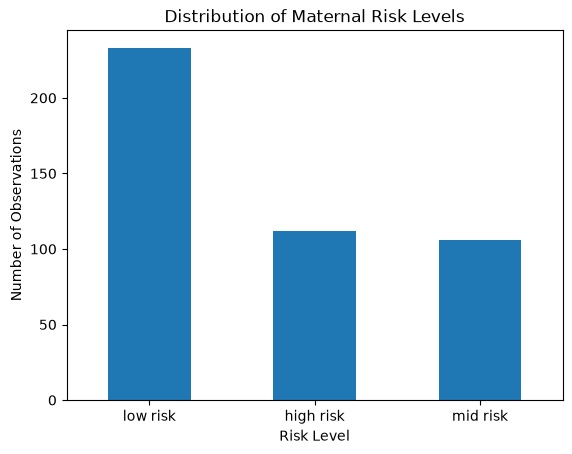

In [28]:
risk_counts = df_clean["RiskLevel"].value_counts()

risk_counts.plot(kind="bar")

plt.title("Distribution of Maternal Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

plt.show()

### Q1 Findings

After preprocessing, Low Risk is the largest group (**51.7%**), followed by High Risk (**24.8%**) and Mid Risk (**23.5%**). Duplicate removal changed the class distribution substantially, especially for the Mid Risk group, showing that duplicated rows were not evenly distributed across labels.

In addition, **35 identical combinations of the six predictors had more than one RiskLevel label**. This indicates label ambiguity, unmeasured clinical information, or limitations of the available predictors. These conflicting profiles were retained rather than automatically treated as labeling errors.

**Figure interpretation:** The RiskLevel bar chart shows moderate class imbalance, with Low Risk representing roughly half of the cleaned observations.


## 5. Q2 — Which Clinical Measurements Differ Across Risk Groups?

Age, blood pressure, blood sugar, body temperature, and heart rate are compared across Low, Mid, and High Risk groups using mean, median, standard deviation, and boxplots.


In [29]:
risk_order = ["low risk", "mid risk", "high risk"]

In [30]:
features = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

group_summary = (
    df_clean
    .groupby("RiskLevel")[features]
    .agg(["mean", "median", "std"])
    .round(2)
    .reindex(risk_order)
)

group_summary

Age               SystolicBP               DiastolicBP         \
            mean median    std       mean median    std        mean median   
RiskLevel                                                                    
low risk   27.37   22.0  13.89     105.37  100.0  15.51       72.72   75.0   
mid risk   28.54   25.5  12.72     112.41  120.0  15.06       74.89   77.5   
high risk  33.73   33.5  13.57     119.49  120.0  20.97       81.54   80.0   

                     BS              BodyTemp              HeartRate         \
             std   mean median   std     mean median   std      mean median   
RiskLevel                                                                     
low risk   13.11   7.20    7.2  0.57    98.36   98.0  1.11     73.04   70.0   
mid risk   12.17   7.89    7.0  2.38    98.86   98.0  1.47     73.90   76.0   
high risk  14.70  11.17   11.0  3.94    99.23   98.0  1.71     76.48   77.0   

                 
            std  
RiskLevel        
low risk   7.02  
mid risk   7.00  
high risk  8.50

In [31]:
mean_by_risk = (
    df_clean
    .groupby("RiskLevel")[features]
    .mean()
    .round(2)
    .reindex(risk_order)
)

mean_by_risk

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
low risk,27.37,105.37,72.72,7.20,98.36,73.04
mid risk,28.54,112.41,74.89,7.89,98.86,73.90
high risk,33.73,119.49,81.54,11.17,99.23,76.48


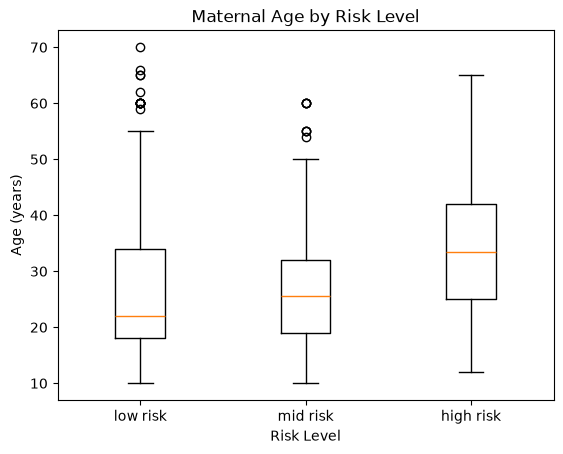

In [32]:
age_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "Age"]
    for level in risk_order
]

plt.boxplot(age_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Maternal Age by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Age (years)")

plt.show()

**Figure interpretation — Age:** High Risk observations tend to have higher maternal age on average, although the distributions overlap substantially across groups.


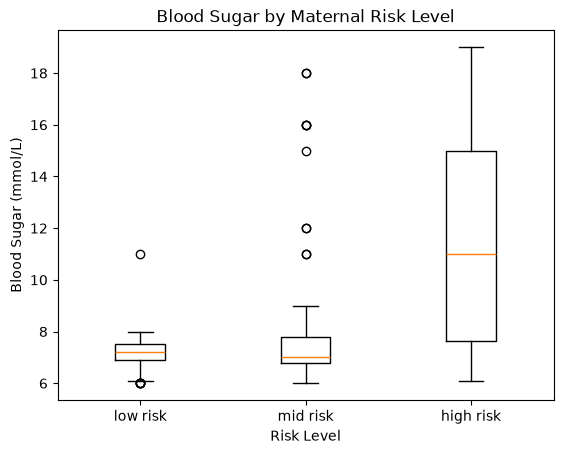

In [33]:
bs_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "BS"]
    for level in risk_order
]

plt.boxplot(bs_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Blood Sugar by Maternal Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Blood Sugar (mmol/L)")

plt.show()

**Figure interpretation — Blood Sugar:** Blood sugar shows the clearest visual separation, with substantially higher values among many High Risk observations.


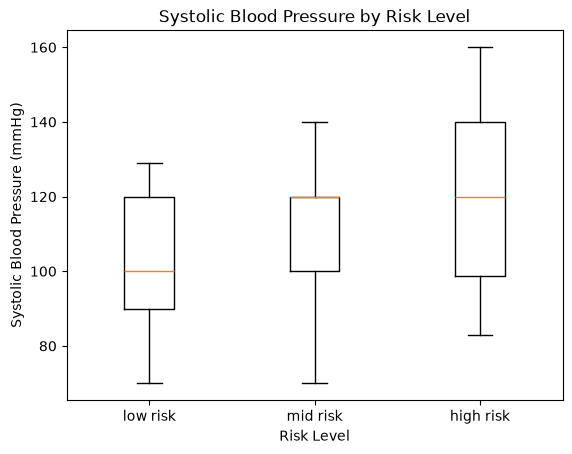

In [34]:
sbp_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "SystolicBP"]
    for level in risk_order
]

plt.boxplot(sbp_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Systolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Systolic Blood Pressure (mmHg)")

plt.show()

**Figure interpretation — Systolic BP:** Systolic blood pressure tends to be higher in the High Risk group, but overlap remains between categories.


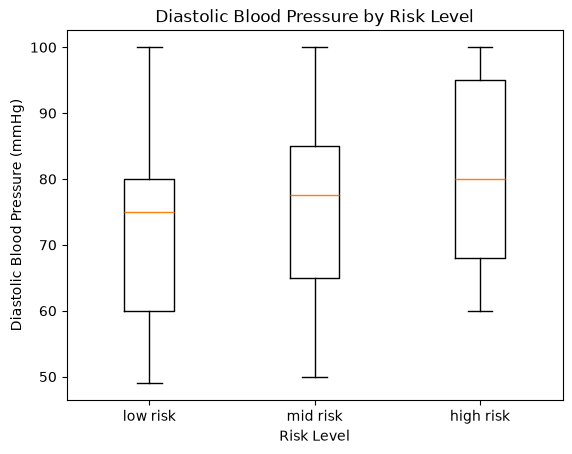

In [35]:
dbp_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "DiastolicBP"]
    for level in risk_order
]

plt.boxplot(dbp_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Diastolic Blood Pressure by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Diastolic Blood Pressure (mmHg)")

plt.show()

**Figure interpretation — Diastolic BP:** Diastolic blood pressure also shifts upward in the High Risk group, with visible overlap among all three categories.


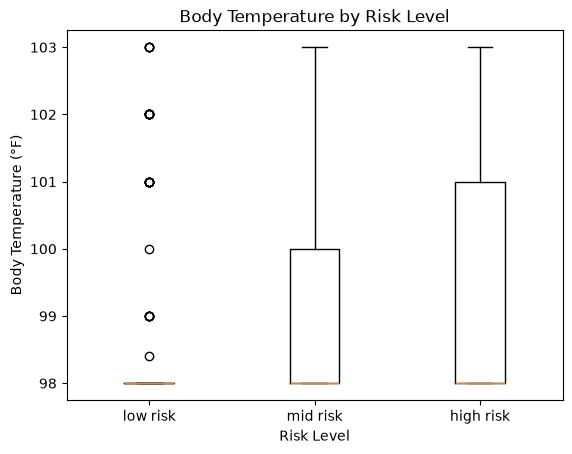

In [36]:
temp_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "BodyTemp"]
    for level in risk_order
]

plt.boxplot(temp_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Body Temperature by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Body Temperature (°F)")

plt.show()

**Figure interpretation — Body Temperature:** Body temperature provides some separation, but most observations are concentrated around 98°F, limiting its discriminatory information.


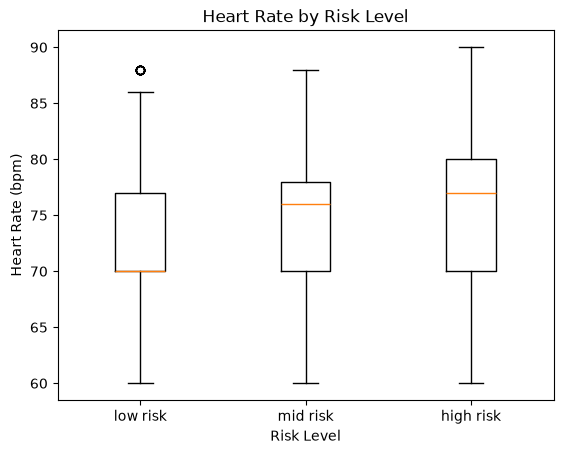

In [37]:
hr_data = [
    df_clean.loc[df_clean["RiskLevel"] == level, "HeartRate"]
    for level in risk_order
]

plt.boxplot(hr_data)

plt.xticks([1, 2, 3], risk_order)
plt.title("Heart Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Heart Rate (bpm)")

plt.show()

**Figure interpretation — Heart Rate:** Heart rate differs less clearly across groups than blood sugar or blood pressure and shows substantial overlap.

### Q2 Findings

Mean values were higher in the High Risk group for all six measurements. The largest descriptive difference was seen in blood sugar, followed by blood-pressure measures. These patterns are descriptive and should not be interpreted as causal effects.


## 6. Q3 — Which Variables Are Most Strongly Associated with High Risk?

High Risk observations are compared with the combined Low/Mid Risk group. Because the predictors are measured on different scales, **Standardized Mean Differences (SMDs)** are used so that the magnitude of group differences can be compared on a common scale.

These comparisons describe association within this dataset and do not establish causation.


In [38]:
df_q3 = df_clean.copy()

df_q3["HighRiskBinary"] = (
    df_q3["RiskLevel"] == "high risk"
).astype(int)

df_q3[["RiskLevel", "HighRiskBinary"]].head()

,RiskLevel,HighRiskBinary
0,high risk,1
1,high risk,1
2,high risk,1
3,high risk,1
4,low risk,0


In [39]:
high_vs_other = (
    df_q3
    .groupby("HighRiskBinary")[features]
    .mean()
    .round(2)
)

high_vs_other

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
HighRiskBinary,,,,,,
0,27.73,107.57,73.40,7.42,98.52,73.31
1,33.73,119.49,81.54,11.17,99.23,76.48


In [40]:
def standardized_mean_difference(data, feature):
    high = data.loc[
        data["RiskLevel"] == "high risk",
        feature
    ]

    other = data.loc[
        data["RiskLevel"] != "high risk",
        feature
    ]

    pooled_sd = np.sqrt(
        (
            (len(high) - 1) * high.std() ** 2
            +
            (len(other) - 1) * other.std() ** 2
        )
        /
        (len(high) + len(other) - 2)
    )

    smd = (high.mean() - other.mean()) / pooled_sd

    return smd

In [41]:
smd_results = pd.Series({
    feature: standardized_mean_difference(df_q3, feature)
    for feature in features
})

smd_results = (
    smd_results
    .abs()
    .sort_values(ascending=False)
)

smd_results

BS             1.612841
SystolicBP     0.695111
DiastolicBP    0.610591
BodyTemp       0.515447
Age            0.443053
HeartRate      0.427998
dtype: float64

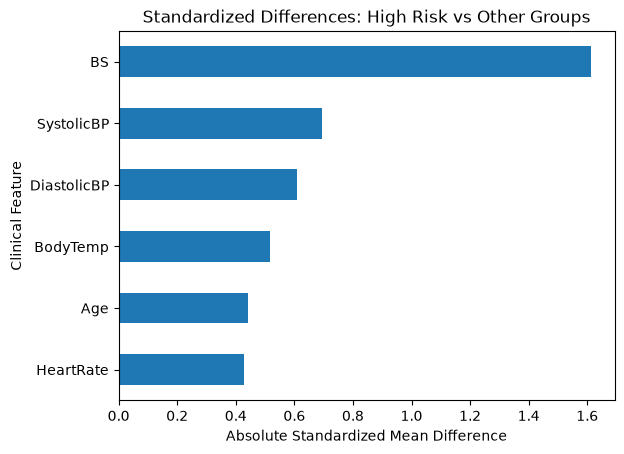

In [42]:
smd_results.sort_values().plot(kind="barh")

plt.title("Standardized Differences: High Risk vs Other Groups")
plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Clinical Feature")

plt.show()

### Q3 Findings

The absolute SMD values were approximately:

- Blood Sugar: **1.61**
- Systolic Blood Pressure: **0.70**
- Diastolic Blood Pressure: **0.61**
- Body Temperature: **0.52**
- Age: **0.44**
- Heart Rate: **0.43**

Blood sugar therefore showed the strongest descriptive separation between High Risk and the other groups.

**Figure interpretation:** The SMD plot ranks variables on a common standardized scale and highlights BS as the largest group difference.


## 7. Q4 — Can a Simple Baseline Model Classify Maternal Risk?

A multiclass Logistic Regression model is used as an interpretable baseline. The dataset is split into 80% training and 20% test data using stratification so that class proportions remain similar in both subsets.


In [43]:
X = df_clean[features]
y = df_clean["RiskLevel"]

In [44]:
y.head()

0    high risk
1    high risk
2    high risk
3    high risk
4     low risk
Name: RiskLevel, dtype: str

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

In [46]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (360, 6)
X_test shape: (91, 6)
y_train shape: (360,)
y_test shape: (91,)


In [47]:
print("Training distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training distribution:
RiskLevel
low risk     0.517
high risk    0.247
mid risk     0.236
Name: proportion, dtype: float64

Test distribution:
RiskLevel
low risk     0.516
high risk    0.253
mid risk     0.231
Name: proportion, dtype: float64


### Train/Test Split Check

The final split contains **360 training observations** and **91 test observations**. Stratification preserved the class proportions closely in both subsets, supporting a fairer class-wise evaluation.


### Model Pipeline

StandardScaler and LogisticRegression are combined in a scikit-learn Pipeline. This ensures that scaling parameters are learned from the training data during model fitting rather than from the complete dataset, reducing preprocessing leakage.


In [48]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

In [49]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['high risk','low risk','mid risk']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [50]:
y_pred = model.predict(X_test)

## 8. Q5 — Is Overall Accuracy Enough?

Model performance is evaluated with Accuracy, Precision, Recall, F1-score, and a Confusion Matrix. Particular attention is given to **High Risk recall**, because missing a genuinely High Risk case is an important error in a health-risk setting.


In [51]:
comparison_pred = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison_pred.head(10)

,Actual,Predicted
225,low risk,low risk
406,high risk,low risk
270,low risk,low risk
449,mid risk,low risk
4,low risk,low risk
94,mid risk,mid risk
109,high risk,high risk
400,mid risk,low risk
314,mid risk,low risk
140,low risk,low risk


In [52]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))

Accuracy: 0.67


In [53]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

              precision    recall  f1-score   support

   high risk      0.812     0.565     0.667        23
    low risk      0.635     1.000     0.777        47
    mid risk      1.000     0.048     0.091        21

    accuracy                          0.670        91
   macro avg      0.816     0.538     0.511        91
weighted avg      0.764     0.670     0.591        91



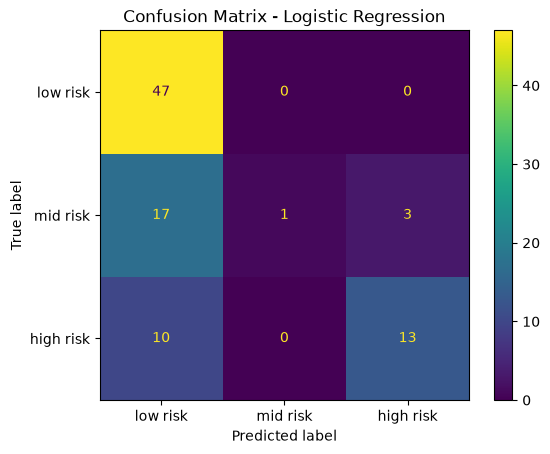

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=risk_order
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Q5 Findings — Model Performance

The baseline Logistic Regression achieved **67.0% accuracy**, but class-wise performance was highly uneven:

- Low Risk recall: **100%**
- High Risk recall: **56.5%**
- Mid Risk recall: **4.8%**

Of the 23 actual High Risk observations in the test set, only 13 were correctly identified. Therefore, approximately **43.5% of High Risk observations were missed**. Only 1 of 21 Mid Risk observations was correctly classified.

**Figure interpretation:** The confusion matrix shows that many Mid Risk and High Risk cases were assigned to Low Risk. This demonstrates why overall accuracy alone is insufficient.


## 9. Q6 — Where Does the Model Fail?

Misclassified test observations are examined to identify systematic error patterns, with special attention to High Risk cases that were predicted as a lower-risk class.


In [55]:
results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

results.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Actual,Predicted,Correct
225,55,120,90,6.9,98.0,76,low risk,low risk,True
406,34,110,70,7.0,98.0,80,high risk,low risk,False
270,30,120,80,7.8,98.0,70,low risk,low risk,True
449,12,100,50,6.0,98.0,70,mid risk,low risk,False
4,35,120,60,6.1,98.0,76,low risk,low risk,True


In [56]:
errors = results[results["Correct"] == False]

errors.head(20)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Actual,Predicted,Correct
406,34,110,70,7.0,98.0,80,high risk,low risk,False
449,12,100,50,6.0,98.0,70,mid risk,low risk,False
400,21,120,80,7.5,98.0,77,mid risk,low risk,False
314,30,120,75,6.8,98.0,70,mid risk,low risk,False
161,25,140,100,7.2,98.0,80,high risk,low risk,False
317,32,120,80,6.8,98.0,70,mid risk,low risk,False
130,25,120,90,6.7,101.0,80,mid risk,high risk,False
64,31,120,60,6.1,98.0,76,mid risk,low risk,False
403,13,90,65,7.5,101.0,80,high risk,low risk,False
263,60,120,80,7.8,98.0,75,high risk,low risk,False


In [57]:
error_types = (
    errors
    .groupby(["Actual", "Predicted"])
    .size()
    .sort_values(ascending=False)
)

error_types

Actual     Predicted
mid risk   low risk     17
high risk  low risk     10
mid risk   high risk     3
dtype: int64

In [58]:
missed_high = results[
    (results["Actual"] == "high risk") &
    (results["Predicted"] != "high risk")
]

missed_high

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Actual,Predicted,Correct
406,34,110,70,7.0,98.0,80,high risk,low risk,False
161,25,140,100,7.2,98.0,80,high risk,low risk,False
403,13,90,65,7.5,101.0,80,high risk,low risk,False
263,60,120,80,7.8,98.0,75,high risk,low risk,False
217,40,120,75,7.7,98.0,70,high risk,low risk,False
118,35,140,100,7.5,98.0,66,high risk,low risk,False
127,32,140,100,6.9,98.0,78,high risk,low risk,False
257,25,100,90,6.9,98.0,76,high risk,low risk,False
436,40,120,95,7.0,98.0,70,high risk,low risk,False
2,29,90,70,8.0,100.0,80,high risk,low risk,False


In [59]:
correct_high = results[
    (results["Actual"] == "high risk") &
    (results["Predicted"] == "high risk")
]

high_error_comparison = pd.DataFrame({
    "Missed High Risk": missed_high[features].mean(),
    "Correctly Identified High Risk": correct_high[features].mean()
}).round(2)

high_error_comparison

,Missed High Risk,Correctly Identified High Risk
Age,33.30,36.77
SystolicBP,117.00,124.23
DiastolicBP,84.50,84.62
BS,7.35,12.81
BodyTemp,98.50,99.08
HeartRate,75.50,80.92


### Q6 Findings — Error Analysis

The major error types were:

- Mid Risk → Low Risk: **17 cases**
- High Risk → Low Risk: **10 cases**
- Mid Risk → High Risk: **3 cases**

All 10 missed High Risk observations were predicted as Low Risk. Missed High Risk cases had a mean BS of approximately **7.35 mmol/L**, compared with **12.81 mmol/L** among correctly identified High Risk cases. This suggests that High Risk observations without strongly elevated blood sugar were harder for this baseline model to recognize.


## 10. Q7 — Which Features Drive the Model?

Because the predictors were standardized before Logistic Regression, the fitted coefficients can be compared as model contributions. Coefficients are interpreted as predictive relationships within this fitted model, not as causal clinical effects.


In [60]:
logreg = model.named_steps["logreg"]

coef_df = pd.DataFrame(
    logreg.coef_,
    columns=features,
    index=logreg.classes_
)

coef_df.round(3)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
high risk,-0.214,0.345,0.178,1.176,0.524,0.166
low risk,0.133,-0.616,0.124,-1.276,-0.507,-0.118
mid risk,0.081,0.271,-0.302,0.100,-0.017,-0.048


In [61]:
high_risk_coef = (
    coef_df
    .loc["high risk"]
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

high_risk_coef

BS             1.176023
BodyTemp       0.524180
SystolicBP     0.344968
Age           -0.214088
DiastolicBP    0.177892
HeartRate      0.165989
Name: high risk, dtype: float64

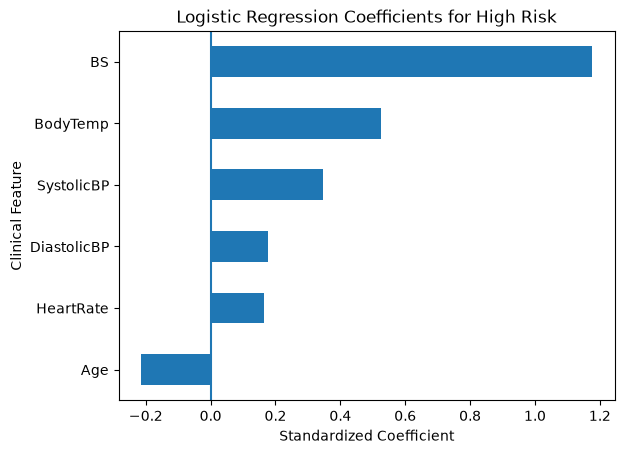

In [62]:
high_risk_coef.sort_values().plot(kind="barh")

plt.title("Logistic Regression Coefficients for High Risk")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Clinical Feature")

plt.axvline(0)

plt.show()

### Q7 Findings — Feature Contributions

For the High Risk class, the largest standardized Logistic Regression coefficient was for **BS (+1.176)**, followed by BodyTemp (+0.524) and SystolicBP (+0.345).

The negative Age coefficient should **not** be interpreted as a protective clinical effect. Multiclass Logistic Regression coefficients are conditional model parameters estimated in the presence of the other predictors.

**Figure interpretation:** The coefficient plot shows which standardized predictors contribute most strongly to the fitted High Risk score. These contributions are predictive, not causal.

## 11. Sensitivity Analysis: Duplicate Handling

Exact repeated rows are unusually common in this dataset. The main analysis removes exact repeated rows before the train and test split because otherwise identical records can appear in both subsets. However, the dataset does not contain patient identifiers, so identical measurements cannot be proven to represent the same person.

To examine how this analytical choice may influence model performance, a second analysis retains the repeated rows after removing only the implausible HeartRate value of 7. To prevent identical predictor profiles from appearing in both training and test data, the sensitivity analysis uses a **stratified grouped split**. Rows with the same six predictor values are assigned to the same fold.

The same Logistic Regression pipeline is then fitted. The comparison focuses on Accuracy, Macro F1, High Risk Recall and Mid Risk Recall. This is a robustness check rather than a replacement for the main model.

In [63]:
# Sensitivity dataset: remove only the implausible HeartRate value.
df_sensitivity = df_raw[df_raw["HeartRate"] != 7].copy()

X_sensitivity = df_sensitivity[features]
y_sensitivity = df_sensitivity["RiskLevel"]

# Rows with identical predictor values receive the same group identifier.
# This prevents the same clinical profile from appearing in both train and test.
profile_groups = (
    df_sensitivity[features]
    .astype(str)
    .agg("|".join, axis=1)
)

group_split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_results = []
profile_overlaps = []

for fold, (train_idx, test_idx) in enumerate(
    group_split.split(X_sensitivity, y_sensitivity, groups=profile_groups),
    start=1,
):
    X_train_sens = X_sensitivity.iloc[train_idx]
    X_test_sens = X_sensitivity.iloc[test_idx]
    y_train_sens = y_sensitivity.iloc[train_idx]
    y_test_sens = y_sensitivity.iloc[test_idx]

    # Confirm that identical predictor profiles do not cross the split.
    train_profiles = set(profile_groups.iloc[train_idx])
    test_profiles = set(profile_groups.iloc[test_idx])
    overlap = len(train_profiles.intersection(test_profiles))
    profile_overlaps.append(overlap)

    sensitivity_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000)),
    ])

    sensitivity_model.fit(X_train_sens, y_train_sens)
    y_pred_sens = sensitivity_model.predict(X_test_sens)

    fold_report = classification_report(
        y_test_sens,
        y_pred_sens,
        output_dict=True,
        zero_division=0,
    )

    fold_results.append({
        "Fold": fold,
        "Train rows": len(train_idx),
        "Test rows": len(test_idx),
        "Accuracy": accuracy_score(y_test_sens, y_pred_sens),
        "Macro F1": fold_report["macro avg"]["f1-score"],
        "High Risk Recall": fold_report["high risk"]["recall"],
        "Mid Risk Recall": fold_report["mid risk"]["recall"],
        "Low Risk Recall": fold_report["low risk"]["recall"],
        "Profile overlap": overlap,
    })

sensitivity_folds = pd.DataFrame(fold_results).set_index("Fold")

metric_columns = [
    "Accuracy",
    "Macro F1",
    "High Risk Recall",
    "Mid Risk Recall",
    "Low Risk Recall",
]

sensitivity_summary = pd.DataFrame({
    "Mean": sensitivity_folds[metric_columns].mean(),
    "SD": sensitivity_folds[metric_columns].std(ddof=1),
})

main_report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0,
)

main_vs_sensitivity = pd.DataFrame({
    "Main holdout": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": main_report["macro avg"]["f1-score"],
        "High Risk Recall": main_report["high risk"]["recall"],
        "Mid Risk Recall": main_report["mid risk"]["recall"],
    },
    "Grouped CV mean": {
        "Accuracy": sensitivity_summary.loc["Accuracy", "Mean"],
        "Macro F1": sensitivity_summary.loc["Macro F1", "Mean"],
        "High Risk Recall": sensitivity_summary.loc["High Risk Recall", "Mean"],
        "Mid Risk Recall": sensitivity_summary.loc["Mid Risk Recall", "Mean"],
    },
    "Grouped CV SD": {
        "Accuracy": sensitivity_summary.loc["Accuracy", "SD"],
        "Macro F1": sensitivity_summary.loc["Macro F1", "SD"],
        "High Risk Recall": sensitivity_summary.loc["High Risk Recall", "SD"],
        "Mid Risk Recall": sensitivity_summary.loc["Mid Risk Recall", "SD"],
    },
})

print("Maximum identical predictor-profile overlap across folds:", max(profile_overlaps))
print("\nFold-level grouped sensitivity results:")
display(sensitivity_folds.round(3))

print("Grouped 5-fold summary (mean and sample SD):")
display(sensitivity_summary.round(3))

print("Main holdout versus grouped sensitivity analysis:")
display(main_vs_sensitivity.round(3))

Maximum identical predictor-profile overlap across folds: 0

Fold-level grouped sensitivity results:


,Train rows,Test rows,Accuracy,Macro F1,High Risk Recall,Mid Risk Recall,Low Risk Recall,Profile overlap
Fold,,,,,,,,
1,809,203,0.586,0.560,0.745,0.134,0.852,0
2,810,202,0.604,0.593,0.691,0.348,0.753,0
3,809,203,0.571,0.563,0.648,0.353,0.704,0
4,810,202,0.634,0.613,0.759,0.294,0.838,0
5,810,202,0.639,0.635,0.630,0.522,0.741,0


Grouped 5-fold summary (mean and sample SD):


,Mean,SD
Accuracy,0.607,0.029
Macro F1,0.593,0.032
High Risk Recall,0.695,0.057
Mid Risk Recall,0.330,0.139
Low Risk Recall,0.777,0.064


Main holdout versus grouped sensitivity analysis:


,Main holdout,Grouped CV mean,Grouped CV SD
Accuracy,0.670,0.607,0.029
Macro F1,0.511,0.593,0.032
High Risk Recall,0.565,0.695,0.057
Mid Risk Recall,0.048,0.330,0.139


### Sensitivity Analysis Results

The grouped sensitivity analysis was repeated across all five folds rather than relying on a single fold. Identical predictor profiles were kept within the same fold, and the maximum train/test profile overlap was **0** in every fold.

Across the five grouped folds, mean Accuracy was **0.607 ± 0.029**, mean Macro F1 was **0.593 ± 0.032**, mean High Risk Recall was **0.695 ± 0.057**, and mean Mid Risk Recall was **0.330 ± 0.139**. Low Risk Recall averaged **0.777 ± 0.064**.

For comparison, the primary analysis based on exact-repeat removal and a single stratified holdout produced Accuracy **0.670**, Macro F1 **0.511**, High Risk Recall **0.565**, and Mid Risk Recall **0.048**. The grouped sensitivity analysis therefore produced lower average Accuracy but higher average Macro F1 and substantially higher Recall for both High Risk and Mid Risk.

These results show that estimated model performance is sensitive to the treatment of repeated observations, especially for class-specific Recall. The two analyses should not be interpreted as a direct model competition because they use different sample definitions and validation procedures. Instead, the sensitivity analysis demonstrates that conclusions about predictive performance depend partly on how repeated measurements are handled. Without patient identifiers, neither duplicate removal nor duplicate retention can be treated as definitively correct.

## 12. Q8 — Clinical Interpretation and Limitations
### Main Findings

Blood sugar showed the strongest descriptive separation and the largest positive model contribution for High Risk. Blood-pressure measurements also differed across risk groups. However, the baseline model had uneven class performance and missed a substantial proportion of High Risk observations while performing especially poorly for Mid Risk in the primary holdout analysis.

The five-fold grouped sensitivity analysis also showed that performance estimates depend on duplicate handling. With repeated observations retained but identical predictor profiles kept within a single fold, mean Accuracy was **0.607**, mean Macro F1 was **0.593**, mean High Risk Recall was **0.695**, and mean Mid Risk Recall was **0.330**. This reinforces the need to report data-quality assumptions alongside model performance.

### Limitations

- The cleaned primary modeling dataset is small (**n = 451**).
- Only six clinical predictors are available.
- Patient identifiers are unavailable, so the true meaning of repeated rows cannot be verified.
- Exact duplicate removal is an analytical assumption and changed the observed class distribution.
- Identical predictor combinations sometimes have different RiskLevel labels, indicating ambiguity or unmeasured information.
- The primary model evaluation is based on one train/test split. The grouped five-fold sensitivity analysis improves robustness assessment, but it does not replace external validation.
- Associations and model coefficients should not be interpreted as causal clinical effects.

### Conclusion

This Logistic Regression model should be treated as an **educational baseline**, not a diagnostic or clinical decision-support system. The analysis shows that class-specific Recall, false-negative inspection, duplicate-handling assumptions, and cautious interpretation are essential in health-data modeling.